# Análise Exploratória de Dados — Mercado de Dados no Brasil (Curso: Programaria)

**Autor:** Ana Luisa

**Dataset:** Pesquisa salarial com profissionais da área de dados (Brasil)

**Tecnologias:** Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly · SQLite · SciPy

---

## Objetivo

Realizar uma análise exploratória completa de uma pesquisa salarial com profissionais de dados, cobrindo:

1. Leitura e inspeção inicial dos dados
2. Filtragem e agrupamentos
3. Estatísticas descritivas
4. Tratamento de valores faltantes
5. Detecção e tratamento de outliers
6. Intervalo de confiança
7. Feature engineering
8. Correlações (Pearson e V de Cramér)
9. Integração com banco de dados SQL
10. Visualização de dados


---
# Módulo 3 — Leitura e Exploração Inicial

## Importações

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency # compara a distribuição observada na tabelacruzada com a distribuição esperada. quanto maior a diferença -> maior chi2 -> associação mais forte
import seaborn as sns
import plotly.express as px


## Leitura dos Dados

In [148]:
dados = pd.read_excel("../../data/planilha_modulo3.xlsx")

## Inspeção Inicial

In [149]:
# Primeiras
dados.head(10)

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Automotivo,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
6,6,zytlxsdgalh22cgrijvzytlxa49i8yzx,21.0,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,4491.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
8,8,zy4o5dk6iuxpdwgzy4o58xvd6ykwohrj,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Sênior,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,7112.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0


In [150]:
# Últimas
dados.tail(10)

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4261,4261,02xomoejng6c9152kde02xomww412qpg,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4262,4262,02vlm03c29g3fcys8tj06102vlm0983h,31.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,de 3 a 4 anos,18402.0
4263,4263,02ido3x5siue5if02iz2taqjmcnh58xh,26.0,25-29,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Júnior,de R$ 6.001/mês a R$ 8.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...,6641.0
4264,4264,028mfisr3mqazkn5n6swe028mt55nqzq,37.0,35-39,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,de 51 a 100,1.0,Gerente/Head,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 3 a 4 anos,Mais de 10 anos,24543.0
4265,4265,01nmlhyw8w2b4stchg01nmlvlcqp0iis,28.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Marketing,de 1 a 5,0.0,NaN,Analista de Marketing,Pleno,de R$ 2.001/mês a R$ 3.000/mês,de 3 a 4 anos,de 1 a 2 anos,2348.0
4266,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos,4329.0
4267,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3758.0
4268,4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,19607.0
4269,4269,00xu7yujd7s57emj00xu7y0c3njix3de,NaN,17-21,Masculino,Branca,Não,NaN,NaN,True,...,Indústria,de 1.001 a 3.000,0.0,NaN,Outra Opção,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,989.0
4270,4270,00lb35llmdsidpa00lb35qcdysnzvhv7,24.0,22-24,Masculino,Branca,Não,NaN,NaN,True,...,Agronegócios,de 501 a 1.000,0.0,NaN,Analista de Dados/Data Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3079.0


In [151]:
dados.shape

(4271, 28)

In [152]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='str')

In [153]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Unnamed: 0                                                                                                                 4271 non-null   int64  
 1   ID                                                                                                                         4271 non-null   str    
 2   IDADE                                                                                                                      4197 non-null   float64
 3   FAIXA IDADE                                                                                                                4271 non-null   

In [154]:
dados.describe()

,Unnamed: 0,IDADE,MUDOU DE ESTADO?,GESTOR?,SALARIO
count,4271.000000,4197.000000,4171.000000,3694.000000,3694.000000
mean,2135.000000,31.169168,0.806281,0.193016,10969.266919
std,1233.075829,6.902803,0.395258,0.394719,19419.753189
min,0.000000,18.000000,0.000000,0.000000,35.000000
25%,1067.500000,26.000000,1.000000,0.000000,4269.500000
50%,2135.000000,30.000000,1.000000,0.000000,7625.500000
75%,3202.500000,35.000000,1.000000,0.000000,12778.500000
max,4270.000000,54.000000,1.000000,1.000000,485191.000000


> **Nota:** O dataset conta com **4.271 respondentes** e **28 colunas**. Algumas colunas relevantes apresentam valores nulos (GENERO, IDADE, SALARIO), que serão tratados na seção 5.

## Filtros

### Por Gênero

In [155]:
dados[dados['GENERO']=='Feminino']

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0
10,10,zwy34gktg0tfjq2ttjvazwy34gg3g49i,25.0,25-29,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,de 101 a 500,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,3450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,4248,070o4zayoboztox764qu070o4zafbqrd,27.0,25-29,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 101 a 500,0.0,NaN,Cientista de Dados/Data Scientist,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,4781.0
4251,4251,068hhicrqggu068huq0l2ab3g7liagy8,34.0,30-34,Feminino,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5673.0
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4259,4259,03n2lq8st9zobnowu3w03n2lqi0flz2w,28.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...","Relação com outros membros da empresa, em mome...",True,...,Finanças ou Bancos,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,24963.0


In [156]:
dados[dados['GENERO']!='Masculino']

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0
10,10,zwy34gktg0tfjq2ttjvazwy34gg3g49i,25.0,25-29,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,de 101 a 500,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,3450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,4248,070o4zayoboztox764qu070o4zafbqrd,27.0,25-29,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 101 a 500,0.0,NaN,Cientista de Dados/Data Scientist,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,4781.0
4251,4251,068hhicrqggu068huq0l2ab3g7liagy8,34.0,30-34,Feminino,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5673.0
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4259,4259,03n2lq8st9zobnowu3w03n2lqi0flz2w,28.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...","Relação com outros membros da empresa, em mome...",True,...,Finanças ou Bancos,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,24963.0


In [157]:
dados[dados['GENERO'].str.contains('não', na=False)]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
562,562,vhuw8xnpbmj6oh20xovhuwcbdl4a12ni,29.0,25-29,Prefiro não informar,Parda,Não,"Sim, acredito que a minha a experiência profis...",Atenção dada pelas pessoas diante das minhas o...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1528,1528,n2ktdn33istvlu1ha4v3kn2ktdn1rsp1,NaN,55+,Prefiro não informar,Indígena,Prefiro não informar,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 51 a 100,0.0,NaN,Analista de Suporte/Analista Técnico,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Menos de 1 ano,826.0
1913,1913,k3as6jdh3w4jf4ztsw4kpkk3as6jdy19,30.0,30-34,Prefiro não informar,Prefiro não informar,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Outra Opção,de 101 a 500,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,de 3 a 4 anos,11476.0
1925,1925,jzppdwep2kpisqjjzppdh304v83cj7eu,NaN,17-21,Prefiro não informar,Prefiro não informar,Prefiro não informar,"Sim, acredito que minha experiência profission...",Quantidade de oportunidades de emprego/vagas r...,False,...,Setor Farmaceutico,de 1 a 5,0.0,NaN,Outra Opção,Júnior,de R$ 2.001/mês a R$ 3.000/mês,de 1 a 2 anos,Menos de 1 ano,2294.0
2554,2554,f5l206z0hr9uh3nz2iiff5l206c0g10o,20.0,17-21,Prefiro não informar,Prefiro não informar,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,de 1 a 2 anos,1339.0
3090,3090,a6ugmsw7s8hu5aa6uglio5apj74fam9o,26.0,25-29,Prefiro não informar,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,de 101 a 500,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,11545.0
3357,3357,7q0icczxn0l3a894cbx7q0icczjyud0n,29.0,25-29,Prefiro não informar,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Júnior,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,6345.0
3493,3493,6m8haop6lxnaizpwij6m8haopiax98jg,25.0,25-29,Prefiro não informar,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 3 a 4 anos,Menos de 1 ano,3900.0
3610,3610,5mloglozmr0r715mntaxbt6xy8b5olmb,30.0,30-34,Prefiro não informar,Branca,Não,"Sim, acredito que a minha a experiência profis...",Velocidade de progressão de carreira,True,...,Tecnologia/Fábrica de Software,de 101 a 500,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 8.001/mês a R$ 12.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...,10174.0
4171,4171,0rksyxnqhn13nwytwi6y0rkssx6jmodf,26.0,25-29,Prefiro não informar,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Outra Opção,de 1.001 a 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Menos de 1 ano,10517.0


### Por Idade

In [158]:
dados[dados['IDADE'] > 30]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4257,4257,043snvbsxn3fuyfe043j5comuyu8g6ba,46.0,45-49,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,1.0,Gerente/Head,NaN,NaN,Acima de R$ 40.001/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,62001.0
4260,4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4261,4261,02xomoejng6c9152kde02xomww412qpg,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4262,4262,02vlm03c29g3fcys8tj06102vlm0983h,31.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,de 3 a 4 anos,18402.0


In [159]:
dados[(dados['IDADE']> 30) & (dados['GENERO'] == 'Feminino')]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
14,14,zwez49k0jhdvfkfst4zwef137uuf4ivy,35.0,35-39,Feminino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Atenção dada pelas pessoas diante das minhas o...,True,...,Varejo,Acima de 3.000,0.0,NaN,Analista de Negócios/Business Analyst,Pleno,de R$ 6.001/mês a R$ 8.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,7416.0
23,23,zuqfcwtl9unfc5ezuqfcwm8coytsp5ap,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,de 5 a 6 anos,13418.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4214,4214,0gprow0ownrbfneftxf0gprow4kyrqdy,41.0,40-44,Feminino,Branca,Prefiro não informar,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Veloc...",True,...,Seguros ou Previdência,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 8.001/mês a R$ 12.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,11452.0
4221,4221,0fgi5bnb0u9b0fgc0jmqlbnvtu12b76d,34.0,30-34,Feminino,Outra,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Outra Opção,Júnior,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5687.0
4240,4240,0a5xgxb1ljmuqn0un8a10a5xg4eufs2l,37.0,35-39,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Finanças ou Bancos,de 51 a 100,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,Menos de 1 ano,1182.0
4247,4247,07qzabp4ujpe4oz81udmb07qzabp4h0t,34.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor de Energia,de 11 a 50,0.0,NaN,Cientista de Dados/Data Scientist,Júnior,de R$ 4.001/mês a R$ 6.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,5925.0


### Por Etnia e Idade (Exercício)

In [160]:
dados[dados['COR/RACA/ETNIA']=='Amarela']

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
13,13,zwh83jpy6x40b95xigsr2zwh83jpflu3,24.0,22-24,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Negócios/Business Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,5296.0
85,85,zfeuk2m9jozahicujlla8zfeuk2g7apj,29.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,97,zbukfwxvpwlk6loglm0zbukfwx6bvyb6,40.0,40-44,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Sênior,de R$ 8.001/mês a R$ 12.000/mês,de 4 a 6 anos,Mais de 10 anos,11388.0
107,107,z9toybzbja7n6xjjbz9f8hmofrry69tg,44.0,40-44,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Indústria,Acima de 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,Mais de 10 anos,14500.0
159,159,ytrnz3zyvn791t3dum1ytrnz3zp22tmk,37.0,35-39,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Aprov...",True,...,Tecnologia/Fábrica de Software,de 101 a 500,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,10628.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4176,4176,0qpa64gqpieg60xpygnajt70qpa64g1a,27.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4207,4207,0ibb8fj9qrwpswfqiil0ibb89e3e4hz3,30.0,30-34,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Veloc...",True,...,Área de Consultoria,de 501 a 1.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,de 5 a 6 anos,16298.0
4210,4210,0hbwm1d1wz739r40hbwm1df6ky5kn4ap,43.0,40-44,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Sênior,de R$ 6.001/mês a R$ 8.000/mês,de 1 a 2 anos,Mais de 10 anos,7131.0
4257,4257,043snvbsxn3fuyfe043j5comuyu8g6ba,46.0,45-49,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,1.0,Gerente/Head,NaN,NaN,Acima de R$ 40.001/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,62001.0


In [161]:
dados[dados['IDADE'] < 40]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Automotivo,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
6,6,zytlxsdgalh22cgrijvzytlxa49i8yzx,21.0,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,4491.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4265,4265,01nmlhyw8w2b4stchg01nmlvlcqp0iis,28.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Marketing,de 1 a 5,0.0,NaN,Analista de Marketing,Pleno,de R$ 2.001/mês a R$ 3.000/mês,de 3 a 4 anos,de 1 a 2 anos,2348.0
4266,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos,4329.0
4267,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3758.0
4268,4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,19607.0


In [162]:
dados[(dados['IDADE'] < 40) & (dados['COR/RACA/ETNIA']=="Amarela")]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
13,13,zwh83jpy6x40b95xigsr2zwh83jpflu3,24.0,22-24,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Negócios/Business Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,5296.0
85,85,zfeuk2m9jozahicujlla8zfeuk2g7apj,29.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,159,ytrnz3zyvn791t3dum1ytrnz3zp22tmk,37.0,35-39,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Aprov...",True,...,Tecnologia/Fábrica de Software,de 101 a 500,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,10628.0
170,170,yri3z491ejizlpj9ylu2k3jyri3z4915,34.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,Acima de 3.000,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...,16650.0
195,195,yjbpxmkqz5yidh5oszyjbpxmkgcb1zd9,32.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3947,3947,2tnsh0gxdu3aq4z2d2tnsh0hk15brx7q,31.0,30-34,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,False,...,Tecnologia/Fábrica de Software,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 25.001/mês a R$ 30.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,29408.0
4058,4058,1t3ndwx8j50k0bz1t3ndwxdpwyg17c2k,27.0,25-29,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...",Nível de cobrança no trabalho / Stress no trab...,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,14175.0
4176,4176,0qpa64gqpieg60xpygnajt70qpa64g1a,27.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4207,4207,0ibb8fj9qrwpswfqiil0ibb89e3e4hz3,30.0,30-34,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Veloc...",True,...,Área de Consultoria,de 501 a 1.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,de 5 a 6 anos,16298.0


## Agrupamentos e Contagens

### Distribuição por Gênero

In [163]:
# Sem valores nulos (padrão)
dados.groupby('GENERO')['ID'].nunique()

GENERO
Feminino                1055
Masculino               3194
Prefiro não informar      12
Name: ID, dtype: int64

In [164]:
# Com valores nulos
dados.groupby('GENERO', dropna=False)['ID'].nunique()

GENERO
Feminino                1055
Masculino               3194
Prefiro não informar      12
NaN                        9
Name: ID, dtype: int64

In [165]:
dados['GENERO'].value_counts(dropna=False)

GENERO
Masculino               3194
Feminino                1056
Prefiro não informar      12
NaN                        9
Name: count, dtype: int64

### Filtros Combinados com Contagem

In [166]:
dados[dados['IDADE'] > 30]['NIVEL'].value_counts()

NIVEL
Sênior    525
Pleno     408
Júnior    274
Name: count, dtype: int64

In [167]:
dados[(dados['IDADE'] > 30) & (dados['GENERO']=="Feminino")]['NIVEL'].value_counts()

NIVEL
Pleno     117
Sênior    114
Júnior     96
Name: count, dtype: int64

### Tabela Dinâmica — Gênero × Gestor

In [168]:
pd.pivot_table(dados, values=['ID'], index=['GENERO'], columns=['GESTOR?'], aggfunc='count')

ID     
GESTOR?                0.0  1.0
GENERO                         
Feminino               754  132
Masculino             2212  578
Prefiro não informar     9    2

---
# Módulo 4 — Estatística Descritiva e Preparação dos Dados

## 4.1 Estatísticas Básicas

### Exemplo com lista manual

In [169]:
# Lista de idades:
idades = [26, 23, 24, 56, 90, 35, 21, 9, 15, 43]

In [170]:
# Soma da idades:
soma = np.sum(idades)
soma

np.int64(342)

In [171]:
# Tamanho Lista:
tam = len(idades)
tam

10

In [172]:
# Média
media1 = soma / tam
media2 = np.mean (idades)

media1
media2

np.float64(34.2)

In [173]:
# Mediana
np.median(idades)

np.float64(25.0)

### Aplicado ao dataset — Idade e Salário

In [174]:
# Média
dados["IDADE"].mean()

np.float64(31.169168453657374)

In [175]:
# Mediana
dados["IDADE"].median()

np.float64(30.0)

In [176]:
# Moda
dados['IDADE'].mode()

0    27.0
Name: IDADE, dtype: float64

In [177]:
# Desvio Padrão
dados['IDADE'].std()

np.float64(6.902802832143122)

In [178]:
# Minino
dados['IDADE'].min()

np.float64(18.0)

In [179]:
# Máximo
dados['IDADE'].max()

np.float64(54.0)

In [180]:
# Média das idades do gênero feminino
dados[dados["GENERO"]=="Feminino"]['IDADE'].mean()

np.float64(31.318051575931232)

In [181]:
# Média das idades do gênero masculino
dados[dados["GENERO"]=="Masculino"]['IDADE'].mean()

np.float64(31.147876077930373)

In [182]:
# Média dos salários
dados["SALARIO"].mean()

np.float64(10969.26691932864)

In [183]:
# Média dos salários do gênero feminino
dados[dados["GENERO"]=="Feminino"]["SALARIO"].mean()

np.float64(8673.22460496614)

In [184]:
# Média dos salários do gênero masculino
dados[dados["GENERO"]=="Masculino"]["SALARIO"].mean()

np.float64(11724.552688172043)

> **Achado:** A média salarial masculina é superior à feminina. Esse padrão será explorado mais adiante na análise de correlações e feature engineering.

## 4.2 Tratamento de Valores Faltantes


### Estratégias disponíveis

| Abordagem | Vantagem | Desvantagem |
|---|---|---|
| Excluir nulos | Simples e rápido | Perde dados; crítico em bases pequenas |
| Substituir por média/mediana/moda | Não perde dados; funciona bem em bases homogêneas | Ignora covariância entre variáveis |
| Modelo de ML (ex: KNN Imputer) | Considera covariância | Mais trabalhoso e computacionalmente custoso |

A estratégia foi escolhida **coluna por coluna**, levando em conta o contexto de cada variável.


In [185]:
# Verificando Na's
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Unnamed: 0                                                                                                                 4271 non-null   int64  
 1   ID                                                                                                                         4271 non-null   str    
 2   IDADE                                                                                                                      4197 non-null   float64
 3   FAIXA IDADE                                                                                                                4271 non-null   

### Coluna GENERO

O formulário oferecia a opção *Prefiro não informar*. Os 9 registros nulos provavelmente refletem quem pulou a pergunta — não uma ausência de identidade. Preenchemos com a mesma categoria.

In [186]:
# Contagem linhas por gênero
dados.groupby('GENERO', dropna=False)['ID'].nunique()

GENERO
Feminino                1055
Masculino               3194
Prefiro não informar      12
NaN                        9
Name: ID, dtype: int64

In [187]:
# Preencher com "Prefiro não informar"
dados['GENERO'] = dados['GENERO'].fillna("Prefiro não informar")

# Verificar
dados.groupby('GENERO', dropna=False)['ID'].nunique()


GENERO
Feminino                1055
Masculino               3194
Prefiro não informar      21
Name: ID, dtype: int64

### Coluna IDADE

São 74 nulos (~1,74% dos dados). Verificamos se os respondentes preencheram a faixa etária — e todos o fizeram. Usamos a **média por faixa etária** como proxy, o que é mais preciso do que a média geral.

In [188]:
# Verificando nulos quantidade de nulos
dados["IDADE"].isnull().value_counts()

IDADE
False    4197
True       74
Name: count, dtype: int64

In [189]:
# Verificar quantas pessoas não preencheram idade mas preencheram faixa etária
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()

FAIXA IDADE
55+      68
17-21     6
Name: count, dtype: int64

In [190]:
# Média 17-21
media_17_21 = dados[dados['FAIXA IDADE']=="17-21"]["IDADE"].mean()

In [191]:
# Localizar linhas e colunas onde idade vazia e faixa etária 17-21
dados.loc[(dados['FAIXA IDADE']=="17-21") & (dados['IDADE'].isnull()), 'IDADE'] = media_17_21

In [192]:
# Verificar
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()

FAIXA IDADE
55+    68
Name: count, dtype: int64

In [193]:
#  Média 55+
dados[dados['FAIXA IDADE']=="55+"]["IDADE"].mean()

nan

> **Nota:** Nenhuma pessoa acima de 55 anos informou a idade exata. Como não há referência por faixa, usamos a média geral — limitação a ser documentada.

In [194]:
#  Média Geral
media_geral = dados["IDADE"].mean()

In [195]:
# Localizar linhas e colunas onde idade vazia e faixa etária 55+
dados.loc[(dados['FAIXA IDADE']=="55+") & (dados['IDADE'].isnull()), 'IDADE'] = media_geral

In [196]:
# Verificar
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()

Series([], Name: count, dtype: int64)

### Coluna SALARIO

São 577 nulos (~13,5%). Nenhum preencheu a faixa salarial. Optamos pela **mediana** em vez da média, pois a análise de outliers ainda não foi feita — a mediana é mais robusta a valores extremos.

In [197]:
dados[dados['SALARIO'].isnull()]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
12,12,zwr9hqcpg513kaopenzwr9hibaqmldto,31.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,28,ztgepgj82o9oix0nztgepq2trcay6gpv,24.0,22-24,Feminino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,34,zsa9i6njd3e594mw0tvlk4zsa9iw86i9,24.0,22-24,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,39,zr4b2vm7dapp3linwqwn7zr4b2vmagqx,32.0,30-34,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,63,zm7o5yquakof0j6zm7vh3o0letznhdvh,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4242,4242,09oxwp6lsdwhw09ox1uobuxa8cq2pzma,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4252,4252,064pe9b1htw7mflhif064pe95dotv6yf,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4260,4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [198]:
dados[dados['SALARIO'].isnull()]['FAIXA SALARIAL'].value_counts()

Series([], Name: count, dtype: int64)

In [199]:
# Mediana
mediana_salario = dados['SALARIO'].median()

In [200]:
# Substituir
dados.loc[dados['SALARIO'].isnull(), 'SALARIO'] = mediana_salario

In [201]:
# Verificar
dados[dados['SALARIO'].isnull()]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO


## 4.3 Detecção e Tratamento de Outliers


### Métodos utilizados

- **Z-score (desvio padrão):** Limite = média ± 3σ.
  Bom para distribuições aproximadamente normais.

- **IQR (intervalo interquartil):**
  Limite = Q1 − 1,5×IQR e Q3 + 1,5×IQR.
  Mais robusto a distribuições assimétricas.

### Abordagens para tratamento

| Abordagem | Quando usar |
|---|---|
| **Remover** | Quando o outlier é erro de digitação ou dado espúrio |
| **Substituir** | Quando o valor é real mas distorce a análise |
| **Manter** | Quando o valor é raro mas válido e relevante |


### Exemplo com lista simulada

In [202]:
# Exemplo
lista_idade =[26,30,32,22,26,35,400,20,43,31,23]

In [203]:
# Média
media = np.mean(lista_idade)
media

np.float64(62.54545454545455)

In [204]:
# Desvio Padrão
desvio = np.std(lista_idade)
desvio

np.float64(106.89532997398872)

In [205]:
# Limite Superior
ls = media + 3*desvio
ls

np.float64(383.2314444674207)

In [206]:
# Limite Inferior
li = media - 3*desvio
li

np.float64(-258.1405353765116)

{'whiskers': [<matplotlib.lines.Line2D at 0x2b13f4dd010>,
 'caps': [<matplotlib.lines.Line2D at 0x2b13f4dd2b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b13f4dcec0>],
 'medians': [<matplotlib.lines.Line2D at 0x2b13f4dd550>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b13f4dd6a0>],
 'means': []}

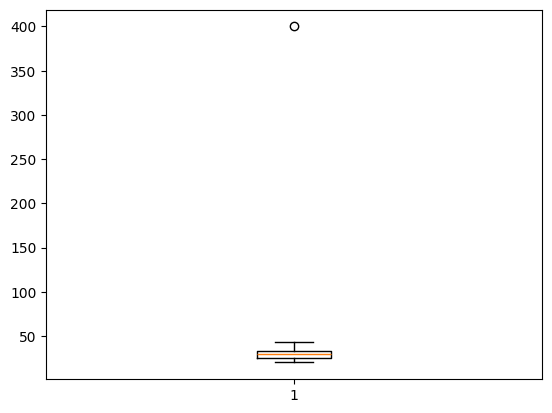

In [207]:
# Visualização - Boxplot
plt.boxplot(lista_idade)

> O boxplot mostra a mediana (linha laranja), Q1 e Q3 (bordas da caixa), os limites (bigodes) e o ponto fora: o outlier.

### Aplicado ao dataset — Salário

{'whiskers': [<matplotlib.lines.Line2D at 0x2b13f54cd70>,
 'caps': [<matplotlib.lines.Line2D at 0x2b13f54d010>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b13f54cc20>],
 'medians': [<matplotlib.lines.Line2D at 0x2b13f54d2b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b13f54d400>],
 'means': []}

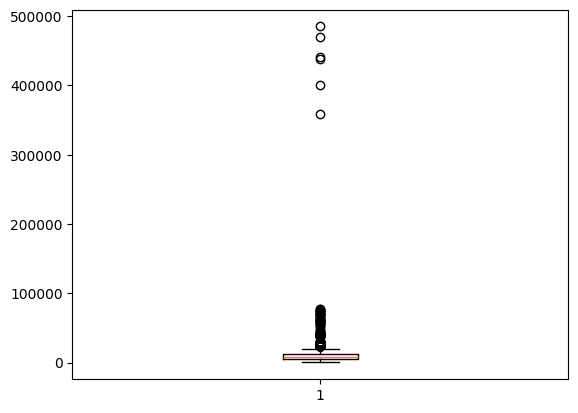

In [208]:
# Verificando outliers da tabela - Salário
plt.boxplot(dados['SALARIO'])

In [209]:
# Q1
q1 = dados['SALARIO'].quantile(0.25)
q1

np.float64(4751.5)

In [210]:
# Q3
q3 = dados['SALARIO'].quantile(0.75)
q3

np.float64(11794.5)

In [211]:
# Interquartil
iqr = q3-q1
iqr

np.float64(7043.0)

In [212]:
# Limite superior com quartis
lim_sup = q3 + (1.5*iqr)
lim_sup

np.float64(22359.0)

In [213]:
# Limite inferior com quartis
lim_inf = q1 - (1.5*iqr)
lim_inf

np.float64(-5813.0)

In [214]:
# média salário
media_salario = dados['SALARIO'].mean()
media_salario

np.float64(10517.53348162023)

In [215]:
# dp sálario
dp_salario = dados['SALARIO'].std()
dp_salario

np.float64(18096.21098911858)

In [216]:
# LS com a parti do desvio
ls_dp = media_salario + (3*dp_salario)
ls_dp

np.float64(64806.166448975964)

In [217]:
# Li com a parti do desvio
li_dp = media_salario - (3*dp_salario)
li_dp

np.float64(-43771.0994857355)

### Tratamento dos outliers de salário

Os salários acima do limite (±3σ) foram substituídos pela **média da faixa salarial correspondente**, preservando a coerência com o contexto declarado pelo respondente.

In [218]:
dados[dados['SALARIO']>ls_dp]['FAIXA SALARIAL'].value_counts()

FAIXA SALARIAL
Acima de R$ 40.001/mês              19
de R$ 30.001/mês a R$ 40.000/mês     3
Name: count, dtype: int64

In [219]:
# media dos 30k a 40k que não são outliers
media_30k_40k = dados[(dados['FAIXA SALARIAL']=="de R$ 30.001/mês a R$ 40.000/mês") & (dados['SALARIO'] <ls_dp)]['SALARIO'].mean()
media_30k_40k

np.float64(39002.19402985075)

In [220]:
# Substituir outliers por média
dados.loc[(dados['FAIXA SALARIAL']=="de R$ 30.001/mês a R$ 40.000/mês") & (dados['SALARIO'] >ls_dp), 'SALARIO'] = media_30k_40k

In [221]:
dados[dados['SALARIO']>ls_dp]['FAIXA SALARIAL'].value_counts()

FAIXA SALARIAL
Acima de R$ 40.001/mês    19
Name: count, dtype: int64

In [222]:
# media dos acima de 40000 
media_mais40k = dados[(dados['FAIXA SALARIAL']=="Acima de R$ 40.001/mês") & (dados['SALARIO'] <ls_dp)]['SALARIO'].mean()
media_mais40k

np.float64(53127.846153846156)

In [223]:
# Substituir outliers por média
dados.loc[(dados['FAIXA SALARIAL']=="Acima de R$ 40.001/mês") & (dados['SALARIO'] >ls_dp), 'SALARIO'] = media_mais40k

In [224]:
dados[dados['SALARIO']>ls_dp]['FAIXA SALARIAL'].value_counts()

Series([], Name: count, dtype: int64)

### Boxplot pós-tratamento

{'whiskers': [<matplotlib.lines.Line2D at 0x2b13efe82f0>,
 'caps': [<matplotlib.lines.Line2D at 0x2b13efe8590>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b13efe81a0>],
 'medians': [<matplotlib.lines.Line2D at 0x2b13efe8830>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b13efe8980>],
 'means': []}

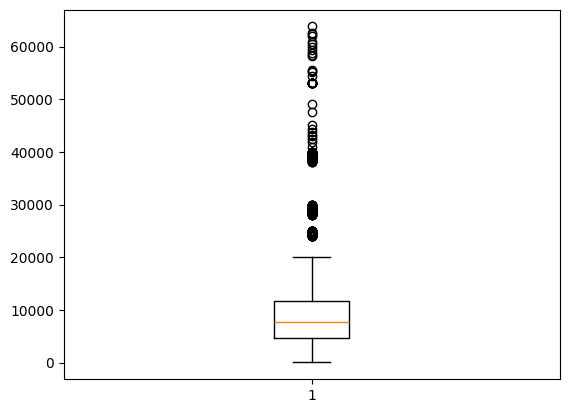

In [225]:
#boxplot pós-correção
plt.boxplot(dados['SALARIO'])

> Após o tratamento, os valores extremos foram suavizados sem remover respondentes do dataset.

## 4.4 Intervalo de Confiança


- **Média amostral:** estimativa de tendência central calculada sobre a amostra
- **Desvio padrão amostral:** dispersão em torno da média
- **Erro padrão:** desvio padrão / √n — mede a precisão da estimativa
- **IC 95%:** intervalo que, se o processo fosse repetido muitas vezes,
  conteria a verdadeira média populacional em 95% dos casos


In [226]:
# Pegar todos os salários
salario = dados['SALARIO']

In [227]:
salario

0       11194.0
1        4695.0
2       14202.0
3       15463.0
4        7733.0
         ...   
4266     4329.0
4267     3758.0
4268    19607.0
4269      989.0
4270     3079.0
Name: SALARIO, Length: 4271, dtype: float64

In [228]:
# Média salários
media_amostral = np.mean(salario)
media_amostral

np.float64(9904.390109813306)

In [229]:
# Desvio Padrão salários
dp_amostral = np.std(salario)
dp_amostral

np.float64(8306.104872579352)

In [230]:
nivel_confianca = 0.95

In [231]:
tamanho_amostra = len(salario)
tamanho_amostra

4271

In [232]:
# Erro Padrão
erro_padrao = stats.sem(salario) # dividindo o desvio padrão da amostra pela raiz quadrada do tamanho da amostra
erro_padrao

np.float64(127.11109872023638)

In [233]:
# Intervalo de confiança com nivel de confiança de 95%
ic = stats.t.interval(nivel_confianca, tamanho_amostra-1, loc=media_amostral, scale= erro_padrao)
ic

(np.float64(9655.186295869078), np.float64(10153.593923757535))

> **Interpretação:** Com 95% de confiança, o salário médio da população de profissionais de dados no Brasil se encontra dentro do intervalo acima.

## 4.5 Feature Engineering


**Engenharia de variáveis:** processo de criar novas colunas derivadas das
existentes para tornar a análise mais expressiva ou preparar os dados para
modelos de Machine Learning.

Variáveis criadas nesta seção:

- NOVO_NIVEL: combina nível hierárquico e se é gestor
- Dummies de NOVO_NIVEL para análise futura
- GERACAO: classifica por geração (Baby Boomer, Gen X, Millennial, Gen Z)
- EM_BUSCA e ABERTO_OPORT: intenção de mudança de emprego
- ETNIA: reagrupamento simplificado de cor/raça/etnia


In [234]:
# Função para preencher coluna "Novo Nível"
def preencher_nivel(gestor, nivel): 
    if gestor:
        return "Pessoa Gestora"
    else:
        return nivel

In [235]:
dados.columns.to_list()

['Unnamed: 0',
 'ID',
 'IDADE',
 'FAIXA IDADE',
 'GENERO',
 'COR/RACA/ETNIA',
 'PCD',
 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA',
 'ASPECTOS_PREJUDICADOS',
 'VIVE_NO_BRASIL',
 'ESTADO ONDE MORA',
 'UF ONDE MORA',
 'REGIAO ONDE MORA',
 'MUDOU DE ESTADO?',
 'REGIAO DE ORIGEM',
 'NIVEL DE ENSINO',
 'ÁREA DE FORMAÇÃO',
 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?',
 'SETOR',
 'NUMERO DE FUNCIONARIOS',
 'GESTOR?',
 'CARGO COMO GESTOR',
 'CARGO ATUAL',
 'NIVEL',
 'FAIXA SALARIAL',
 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
 'SALARIO']

In [236]:
# Apply -> Função que permite aplicar funções em colunas ou tabelas
dados['NOVO_NIVEL'] = dados.apply(lambda x: preencher_nivel(x['GESTOR?'], x['NIVEL']), axis=1) #axis=1 pq queremos aplicar nas linhas, por padrão é 0 (colunas)

In [237]:
dados['NOVO_NIVEL'].value_counts()

NOVO_NIVEL
Pessoa Gestora    1290
Pleno             1060
Júnior            1023
Sênior             898
Name: count, dtype: int64

In [238]:
# converter variaveis categoricas em variaveis indicadoras -> get_dummies
dados = pd.get_dummies(dados, columns=['NIVEL'])


In [239]:
# Função que determina geração
def determina_geracao(idade):
    if  39 < idade <= 58:
        return "Geração X"
    elif 29 < idade <= 39:
        return "Millenial"
    elif 13 < idade <= 29:
        return "Geração Z"
    else:
        return "Outra Geração"


In [240]:
# converter variaveis continuas em variaveis discretas
dados['GERACAO'] = dados['IDADE'].apply(determina_geracao)

In [241]:
dados['GERACAO'].value_counts()

GERACAO
Geração Z    1999
Millenial    1761
Geração X     511
Name: count, dtype: int64

### Merge com segunda tabela — intenção de mudança de emprego

In [242]:
# Lendo 2ª tabela
dados2 = pd.read_excel("../../data/planilha_modulo4.xlsx")

In [243]:
dados2.head()

,ID,Quanto tempo de experiência na área de dados você tem?,Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?,Você está satisfeito na sua empresa atual?,Qual o principal motivo da sua insatisfação com a empresa atual?,Você participou de entrevistas de emprego nos últimos 6 meses?,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,de 1 a 2 anos,de 7 a 10 anos,True,NaN,Não participei de entrevistas de emprego/proce...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL
1,zzls2oftfn9law393oezzls2ofhvfpzd,de 3 a 4 anos,Menos de 1 ano,False,Falta de oportunidade de crescimento no empreg...,"Sim, fiz entrevistas mas não fui aprovado",Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,de 3 a 4 anos,Mais de 10 anos,False,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,1
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,True,NaN,"Sim, fui aprovado e mudei de emprego","Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,Não tenho experiência na área de dados,Mais de 10 anos,False,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL


In [244]:
# Merge de tabelas
dados = dados.merge(dados2, on='ID', how='left')


In [245]:
# Verificando quantidade para cada resposta da pergunta
dados['Você pretende mudar de emprego nos próximos 6 meses?'].value_counts()

Você pretende mudar de emprego nos próximos 6 meses?
Não estou buscando, mas me considero aberto a outras oportunidades         1354
Estou em busca de oportunidades dentro ou fora do Brasil                   1011
Não estou buscando e não pretendo mudar de emprego nos próximos 6 meses     978
Estou em busca de oportunidades, mas apenas fora do Brasil                  353
Name: count, dtype: int64

In [246]:
# Coluna nova para todos que estão em busca
dados['EM_BUSCA'] = dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains("em busca", case=False)

In [247]:
dados['EM_BUSCA'].value_counts()

EM_BUSCA
False    2909
True     1364
Name: count, dtype: int64

In [248]:
# colunas novas para quem está aberto a possibilidade
dados['ABERTO_OPORT'] = dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains("aberto", case=False)

In [249]:
dados['ABERTO_OPORT'].value_counts()

ABERTO_OPORT
False    2919
True     1354
Name: count, dtype: int64

### Classificação de etnia (Exercício)

In [250]:
dados['COR/RACA/ETNIA'].value_counts()

COR/RACA/ETNIA
Branca                  2746
Parda                   1054
Preta                    291
Amarela                  128
Prefiro não informar      26
Outra                     17
Indígena                  11
Name: count, dtype: int64

In [251]:
# função para definir se branca, não branca e outras
def determina_etnia(etnia):
    if etnia == "Branca":
        return etnia
    elif etnia == "Outra":
        return etnia
    elif etnia == "Prefiro não informar":
        return etnia
    else:
        return "Não Branca"


In [252]:
dados['ETNIA'] = dados['COR/RACA/ETNIA'].apply(determina_etnia)

In [253]:
dados['ETNIA'].value_counts()

ETNIA
Branca                  2746
Não Branca              1484
Prefiro não informar      26
Outra                     17
Name: count, dtype: int64

## 4.6 Correlações


A correlação mede se e como duas variáveis se relacionam.

| Tipo de variável | Métrica | Faixa |
|---|---|---|
| Contínua × Contínua | **Pearson** | −1 a +1 |
| Categórica × Categórica | **V de Cramér** | 0 a 1 |

- Pearson próximo de ±1 → correlação linear forte
- V de Cramér próximo de 1 → associação forte entre categorias


In [254]:
# Correlação entre idade e salario
correlacao_continua = dados['IDADE'].corr(dados['SALARIO'])
correlacao_continua

np.float64(0.29024419686221)

> **Resultado:** Correlação positiva fraca entre idade e salário (r ≈ 0,29). Idade influencia, mas não determina o salário sozinha.

In [255]:
# Correlação de cramer
def cramer_coeficiente(coluna1, coluna2):
    # Tabela Cruzada -> Frequencia de que os dados das tabelas se cruzam
    tabela_cruzada = np.array(pd.crosstab(coluna1, coluna2)) 

    chi2 = chi2_contingency(tabela_cruzada)[0]

    soma = np.sum(tabela_cruzada)

    mini = min(tabela_cruzada.shape)-1

    cramer = np.sqrt(chi2/(soma*mini))

    return cramer

In [256]:
cramer_coeficiente(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])

np.float64(0.04499106580480143)

> V de Cramér ≈ 0,045 entre cor/raça/etnia e nível de ensino → associação muito fraca.

In [257]:
cramer_coeficiente(dados['GENERO'], dados['NIVEL DE ENSINO'])

np.float64(0.076119232802818)

> V de Cramér ≈ 0,076 entre gênero e nível de ensino → associação muito fraca.

---
# Módulo 5 — Integração com Banco de Dados SQL

Conectamos ao banco SQLite statusbrasil para enriquecer o dataset com **renda média municipal** por estado, cruzando dados da pesquisa com indicadores socioeconômicos externos.

In [258]:
# Importando biblioteca
import sqlite3

In [259]:
# Conexão com o banco
conexao_bd = sqlite3.connect('../sql/statusbrasil')

### Consulta de teste

In [260]:
query = 'SELECT * FROM Municipios_Brasileiros WHERE Cidade LIKE "Itaquaqu%"'

In [261]:
query

'SELECT * FROM Municipios_Brasileiros WHERE Cidade LIKE "Itaquaqu%"'

In [262]:
pd.read_sql(query, con=conexao_bd)

,Cidade,Estado,Regiao,municipio_ID
0,Itaquaquecetuba,SP,Sudeste,5043


### Renda média por estado — JOIN entre tabelas

In [263]:
query = "SELECT Estado, AVG(Renda) FROM Municipios_Brasileiros mb INNER JOIN Municipios_Status ms ON mb.municipio_ID = ms.municipio_ID GROUP BY Estado"

In [264]:
pd.read_sql(query, con=conexao_bd)

,Estado,AVG(Renda)
0,AC,0.585455
1,AL,0.548363
2,AM,0.545113
3,AP,0.618875
4,BA,0.574805
5,CE,0.559293
6,DF,0.863000
7,ES,0.680628
8,GO,0.683980
9,MA,0.531664


### Filtrar apenas estados presentes na pesquisa e fazer merge

In [265]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

In [266]:
# Lista dos estados da pesquisa
estado_pesquisa = list(dados['UF ONDE MORA'].unique())

In [267]:
query = "SELECT Estado, AVG(Renda) FROM Municipios_Brasileiros mb INNER JOIN Municipios_Status ms ON mb.municipio_ID = ms.municipio_ID WHERE mb.Estado IN ({}) GROUP BY mb.Estado".format(','.join(['?' for _ in estado_pesquisa]))

In [268]:
estados_renda = pd.read_sql(query, con=conexao_bd, params=estado_pesquisa)

In [269]:
dados.rename(columns={'UF ONDE MORA': 'Estado'}, inplace=True)

In [270]:
dados = dados.merge(estados_renda, on="Estado",how ='left')

In [271]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'Estado', 'REGIAO ONDE MORA',
       'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO',
       'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [272]:
# Correlação entre renda e salario
correlacao_salario_renda = dados['SALARIO'].corr(dados['AVG(Renda)'])
correlacao_salario_renda

np.float64(0.12083384881429413)

> **Resultado:** Correlação ≈ 0,12 entre renda média do estado e salário individual — positiva, mas fraca. O estado de residência não é um preditor forte de salário na área de dados.

### Exercício — Correlação entre nível de escolaridade e renda do estado

In [273]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'Estado', 'REGIAO ONDE MORA',
       'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO',
       'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [274]:
dados['NIVEL DE ENSINO'].unique()

<StringArray>
[             'Pós-graduação',      'Graduação/Bacharelado',
           'Doutorado ou Phd',     'Estudante de Graduação',
                   'Mestrado', 'Não tenho graduação formal',
       'Prefiro não informar']
Length: 7, dtype: str

In [275]:
mapa_educacao = {
    'Não tenho graduação formal': 1,
    'Estudante de Graduação': 2,
    'Graduação/Bacharelado': 3,
    'Mestrado': 5,
    'Doutorado ou Phd': 6,
    'Pós-graduação': 4,  
    'Prefiro não informar': 0
}

In [276]:
dados['NIVEL_NUM'] = dados['NIVEL DE ENSINO'].map(mapa_educacao)

In [277]:
correlacao_educacao_renda = dados['NIVEL_NUM'].corr(dados['AVG(Renda)'])
correlacao_educacao_renda

np.float64(0.024304471971877014)

> **Resultado:** Correlação ≈ 0,024 entre nível de ensino e renda média do estado — praticamente nula. O nível de escolaridade do profissional não se correlaciona com a renda média do estado onde mora.

---
# Módulo 6 — Visualização de Dados

## Distribuição por Gênero

In [278]:
genero_counts = dados['GENERO'].value_counts()

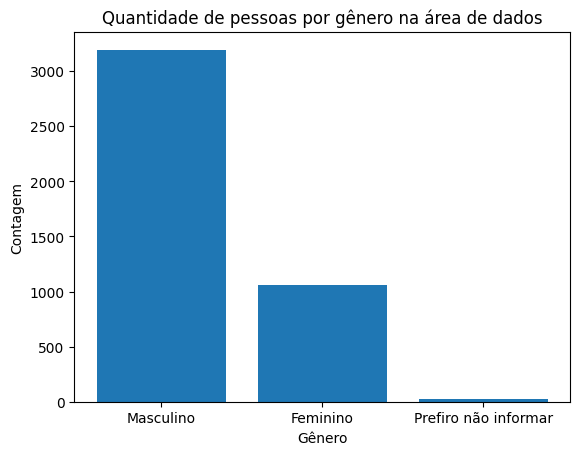

In [279]:
# Gráfico barras: gênero - MATPLOT
plt.figure() # Cria janela
plt.bar(height= genero_counts.values, x = genero_counts.index) # Gráfico de barras
plt.title("Quantidade de pessoas por gênero na área de dados") # Adiciona titúlo
plt.xlabel("Gênero")
plt.ylabel("Contagem")

plt.show()


> O gráfico acima usa Matplotlib. Abaixo, o mesmo conteúdo com Seaborn para comparação de sintaxe e estética.

C:\Users\analu\AppData\Local\Temp\ipykernel_24128\316184246.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= dados, x='GENERO', palette='bright')


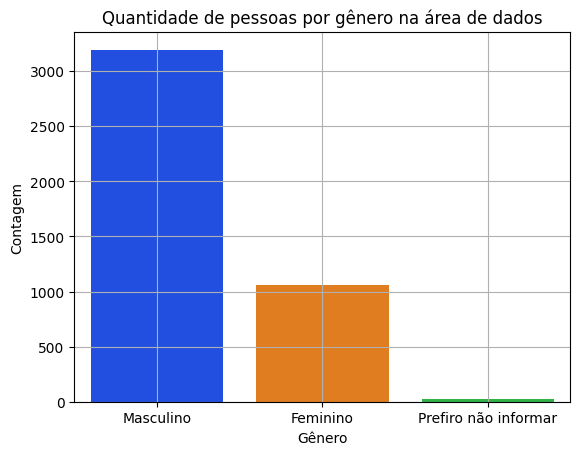

In [280]:
# Gráfico barras: gênero - SEABORN
plt.figure()
sns.countplot(data= dados, x='GENERO', palette='bright')
plt.title("Quantidade de pessoas por gênero na área de dados") # Adiciona titúlo
plt.xlabel("Gênero")
plt.ylabel("Contagem")
plt.grid(True)

plt.show()


> **Leitura:** A maioria dos respondentes é do gênero masculino. A sub-representação feminina na área de dados é um padrão documentado no mercado brasileiro.

## Salário Médio por Idade

In [281]:
media_salario_idade = dados.groupby("IDADE")['SALARIO'].mean()
media_salario_idade

IDADE
18.000000     4230.307692
19.000000     4519.590909
20.000000     5004.272727
20.205479     3536.000000
21.000000     4578.737179
22.000000     4394.689815
23.000000     5602.406897
24.000000     6151.622449
25.000000     7616.392336
26.000000     7700.071174
27.000000     8237.429766
28.000000     9737.938144
29.000000     9554.853147
30.000000    10316.412686
31.000000    10021.462609
31.153517     9646.330882
32.000000    10843.197778
33.000000    11592.718590
34.000000    12294.640212
35.000000    12435.845105
36.000000    12267.966533
37.000000    12613.528357
38.000000    13802.724874
39.000000    13309.082898
40.000000    15028.032721
41.000000    13578.880952
42.000000    11801.037037
43.000000    14349.732278
44.000000    14665.770147
45.000000    16103.431520
46.000000    11913.709677
47.000000    11156.031250
48.000000    12249.714286
49.000000    14556.000000
50.000000    15740.010181
51.000000     8977.900000
52.000000    11779.475000
53.000000     9850.000000
54.000

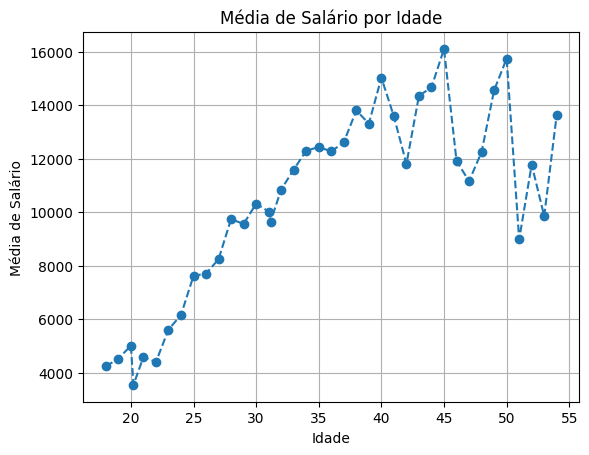

In [282]:
# gráfico - MATPLOT
plt.figure()
plt.plot(media_salario_idade.index, media_salario_idade.values, marker='o', linestyle='--')
plt.title("Média de Salário por Idade")
plt.xlabel("Idade")
plt.ylabel("Média de Salário")
plt.grid(True)

plt.show()

> O gráfico interativo abaixo (Plotly) permite zoom e hover com os valores.

In [283]:
fig = px.line(media_salario_idade.reset_index(), x='IDADE', y='SALARIO', title='Média de salário por idade', markers=True)
fig.show()

> **Leitura:** O salário médio tende a crescer com a idade, mas com bastante variação — o que é consistente com a correlação de Pearson fraca (≈ 0,29) calculada anteriormente.

## Dispersão Salário × Idade

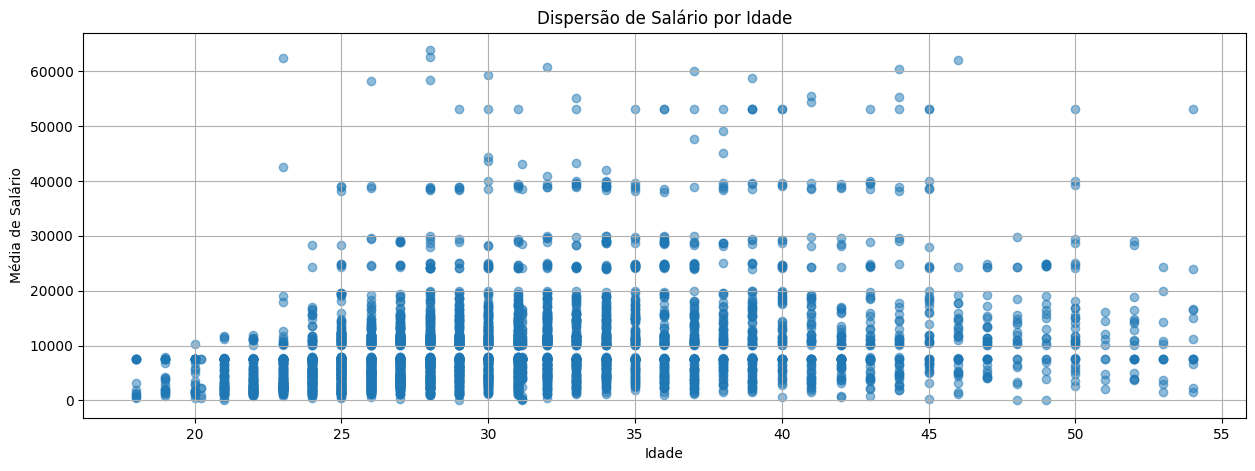

In [284]:
# scatter plot - MATPLOT
plt.figure(figsize=(15,5)) #figsize -> tamanho da janela
plt.scatter(dados['IDADE'], dados['SALARIO'], alpha=0.5)
plt.title("Dispersão de Salário por Idade")
plt.xlabel("Idade")
plt.ylabel("Média de Salário")
plt.grid(True)

In [285]:
# scatter - PLOTLY
fig = px.scatter(dados, x='IDADE', y='SALARIO', title='Dispersão de salário por idade')
fig.show()

> **Leitura:** A nuvem de pontos confirma a tendência de crescimento salarial com a idade, mas com grande dispersão em todas as faixas — especialmente entre 25 e 40 anos, onde se concentra a maioria dos profissionais.

---
# Conclusões e Próximos Passos


## Principais Achados

| Variável analisada | Resultado |
|---|---|
| Tamanho do dataset | 4.271 respondentes, 28 colunas |
| Nulos tratados | GENERO (9), IDADE (74), SALARIO (577) |
| Salário médio | Disponível nas células de estatísticas (seção 4.1) |
| Correlação Idade × Salário | Pearson ≈ 0,29 — positiva e fraca |
| Correlação Renda do Estado × Salário | Pearson ≈ 0,12 — positiva e muito fraca |
| Associação Etnia × Nível de Ensino | V de Cramér ≈ 0,045 — muito fraca |
| Associação Gênero × Nível de Ensino | V de Cramér ≈ 0,076 — muito fraca |

## Conclusão Geral

As variáveis demográficas isoladas (idade, gênero, etnia e estado)
têm baixa capacidade preditiva individual sobre o salário.

Isso sugere que a remuneração na área de dados é determinada por uma
combinação de fatores — nível hierárquico, tempo de experiência,
setor da empresa e especialização técnica.

Esses fatores serão explorados no próximo notebook (Módulo 7)
utilizando um modelo de Regressão Linear.

## Próximos Passos

- **Módulo 7:** Construção de modelo preditivo de salário com Regressão Linear
